In [2]:
# ADDS THE PARENT DIRECTORY TO SYS.PATH
import sys
import os

# Add the project root directory (one level up) to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
from src.integrator.integrate import phi, phi_inv

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## Interpolate the boundary of D0

In [12]:
e0 = 0.5
bound_tv = np.load("../boundary_test1/e0_5__v2_eps0_001__deltmax_100.npy")

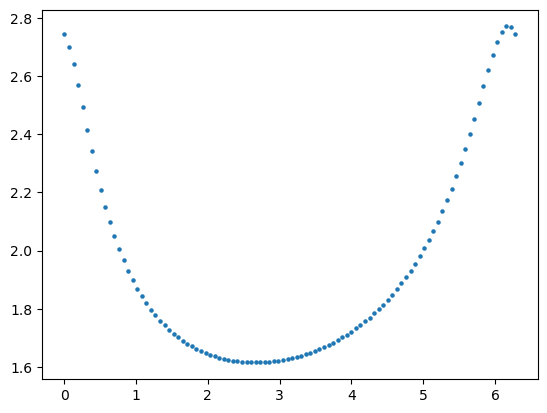

In [16]:
plt.scatter(bound_tv[0], bound_tv[1], s = 5)

In [ ]:
v_data = bound_tv[1,:-1]
t_data = bound_tv[0,:-1]

N = len(v_data)

# Fourier coefficients
c_four = np.fft.fft(v_data) / N

# integer wave numbers: 0,1,...,N/2-1,-N/2,...,-1
k_four = np.fft.fftfreq(N) * N

# We remove higher order modes (np.abs(c_four) <= 1e-5)
# They just represent noise
k_cut = 20
c_four[np.abs(k_four) > k_cut] = 0

def interpol_D0_v(t):
    t = np.asarray(t) % (2*np.pi)   # enforce periodicity
    phases = np.exp(1j * np.outer(k_four, t))
    vals = (c_four[:, None] * phases).sum(axis=0)
    return vals.real


## Compute escape time landscape

In [96]:
def iterations_before_escape(e, v, t, t_max, max_iter=1000):
    n = 0
    while n < max_iter:
        v, t = phi(e, v, t, t_max=t_max)
        if v is None:
            return n
        n += 1
    return n

N_sample = 3000
t_samples = np.random.uniform(0, 2*np.pi, N_sample)
v_max_samples = interpol_D0_v(t_samples)
v_samples = np.random.uniform(0, v_max_samples)
escape_iter_samples = np.zeros((N_sample,))

# We define escape time computation parameters
t_max_escape = 100
max_iter_escape = 20

escape_iters = []
for i in range(N_sample):
    v = v_samples[i]
    t = t_samples[i]
    n_iter = iterations_before_escape(e0, v, t, t_max=t_max_escape, max_iter=max_iter_escape)
    escape_iter_samples[i] = n_iter

escape_iters = np.array(escape_iters)

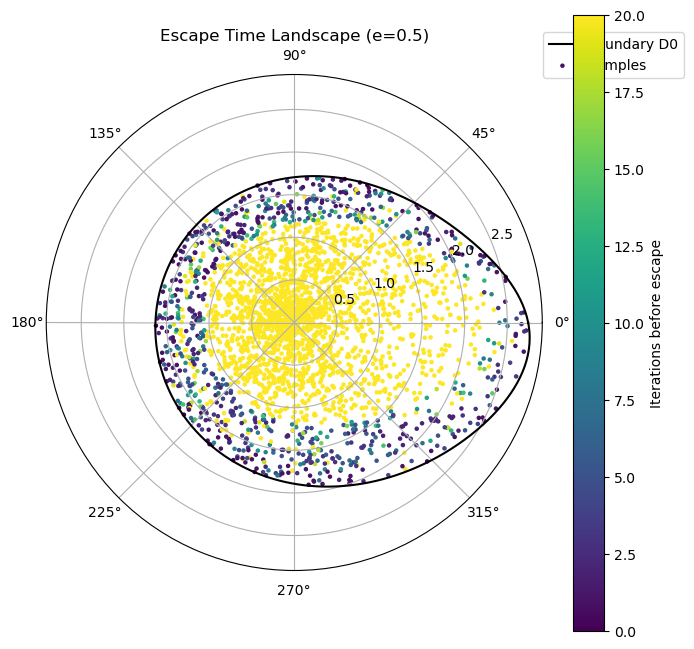

In [ ]:
t_val = np.linspace(0, 2*np.pi, 500)
v_val = interpol_D0_v(t_val) # Assuming you want the boundary line too

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

# Plot the boundary line
ax.plot(t_val, v_val, color='black', label='Boundary D0')

# Scatter plot of the sampled points, colored by escape time
# Using 't_samples' for theta and 'v_samples' for radius (r)
sc = ax.scatter(t_samples, v_samples, c=escape_iter_samples, cmap='viridis', s=5, label='Samples')

# Add a colorbar
plt.colorbar(sc, label='Iterations before escape')

ax.set_title(f'Escape Time Landscape (e={e0})')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Save the figure
fig.savefig('../figures/escape_time_landscape_polar.png', dpi=300, bbox_inches='tight')

plt.show()

## Storing my data and improving my computation methods

# Store my data!!

In [111]:
np.savez(f'../boundary_test1/escape_time_samples_e{e0}.npz', 
         v=v_samples, 
         t=t_samples, 
         iterations=escape_iter_samples)


In [112]:
saved_data = np.load("../boundary_test1/escape_time_samples_e0.5.npz")

In [113]:
print(saved_data['iterations'])

[ 1. 20. 20. ... 10. 20. 20.]


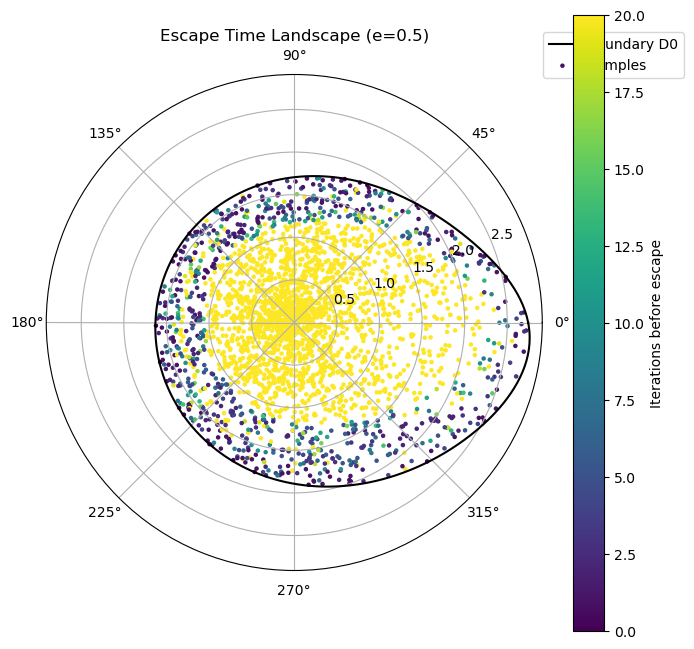

In [ ]:
t_val = np.linspace(0, 2*np.pi, 500)
v_val = interpol_D0_v(t_val) # Assuming you want the boundary line too

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

# Plot the boundary line
ax.plot(t_val, v_val, color='black', label='Boundary D0')

# Scatter plot of the sampled points, colored by escape time
# Using 't_samples' for theta and 'v_samples' for radius (r)
sc = ax.scatter(t, v, c=iterations, cmap='viridis', s=5, label='Samples')

# Add a colorbar
plt.colorbar(sc, label='Iterations before escape')

ax.set_title(f'Escape Time Landscape (e={e0})')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Save the figure
fig.savefig('../figures/escape_time_landscape_polar.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:

bound_KAM_island = np.array([])

v_data = bound_KAM_island
t_data = bound_KAM_island

N = len(v_data)

# Fourier coefficients
c_four_center = np.fft.fft(v_data) / N

# integer wave numbers: 0,1,...,N/2-1,-N/2,...,-1
k_four_center = np.fft.fftfreq(N) * N


def interpol_D0_v(t):
    t = np.asarray(t) % (2*np.pi)   # enforce periodicity
    phases = np.exp(1j * np.outer(k_four_center, t))
    vals = (c_four_center[:, None] * phases).sum(axis=0)
    return vals.real

In [ ]:
def filter